In [128]:
import pandas as pd
import sklearn
import csv
import matplotlib.pyplot as plt 
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
# Daniel Cho -- old fashioned homo sapiens code and a lot of documentation reading (i.e., no AI code)

In [129]:
# just some preliminary analysis to see structure of data. for actual homework steps skip 5-6 cells.
'''
   1. sepal length in cm
   2. sepal width in cm
   3. petal length in cm
   4. petal width in cm
   5. class: 
      -- Iris Setosa
      -- Iris Versicolour
      -- Iris Virginica
'''
columns = ['len_sepal', 'wid_sepal', 'len_petal', 'petal_wid', 'class']

In [130]:
data = pd.read_csv('data/iris/iris.data', names=columns)

In [131]:
print(f'Shape: {data.shape}, Size: {data.size}')

Shape: (150, 5), Size: 750


In [132]:
data

,len_sepal,wid_sepal,len_petal,petal_wid,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [133]:
X = data.iloc[:,:3]
X

,len_sepal,wid_sepal,len_petal
0,5.1,3.5,1.4
1,4.9,3.0,1.4
2,4.7,3.2,1.3
3,4.6,3.1,1.5
4,5.0,3.6,1.4
...,...,...,...
145,6.7,3.0,5.2
146,6.3,2.5,5.0
147,6.5,3.0,5.2
148,6.2,3.4,5.4


In [134]:
y = data.iloc[:,4] 
y

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: class, Length: 150, dtype: object

In [135]:
# goal: create a scikit-learn pipeline that predicts the class column using the other columns
# 1. Use the scikit-learn Pipeline abstraction to build your pipeline
# 2. Create one or more scatterplots like those shown on the Iris data Wikipedia page.
# 3. Split the dataset into training and test data, about 80% for the former and 20% for thelatter. Ideally use scikit-learn
# 4. Required: Pick any supervised learning technique supported by scikit-learn.
#     4.1Train a model on the training data.
#     4.2Evaluate the model on the test data.
# 5. Required: Report the model’s accuracy on the test data.
# 6. Explore model hyperparameters and report how changing their values affects accuracy.
# 7. Report the confusion matrix.

In [136]:
# 1. Use the scikit-learn Pipeline abstraction to build your pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=3)),
])

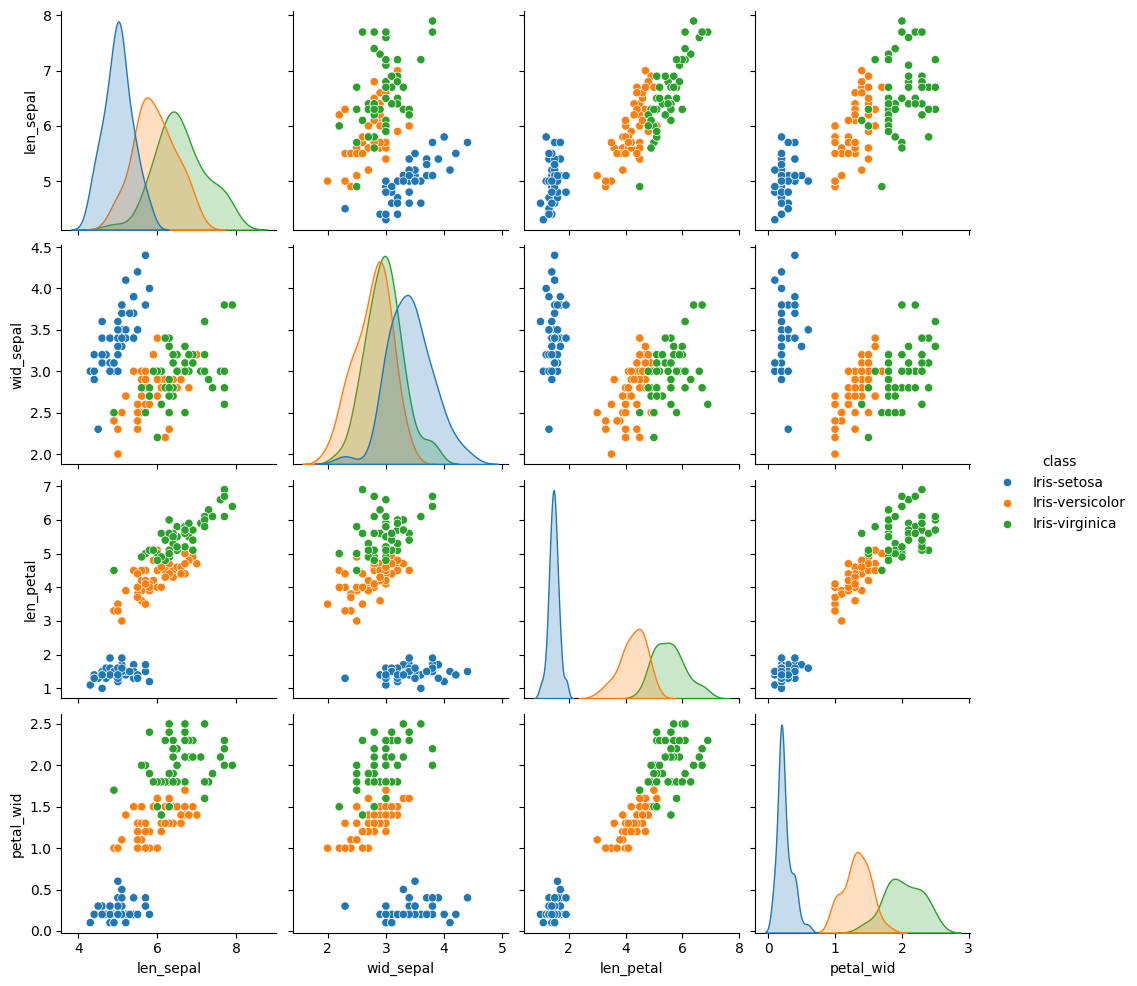

In [137]:
# 2. Create one or more scatterplots like those shown on the Iris data Wikipedia page.
import seaborn as sns 
# using seaborn because it makes scatter plot matrices very easy 
sns.pairplot(data=data, hue='class')

In [138]:
# 3. Split the dataset into training and test data, about 80% for the former and 20% for thelatter. Ideally use scikit-learn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [139]:
# 4. Required: Pick any supervised learning technique supported by scikit-learn.
# i am going to choose nearest neighbour. i dont think it has an edge over decision trees, but LR is definitely the worst choice 
# imo since i dont think it can capture the multi-classification task as well as the other 2. 

#     4.1Train a model on the training data.
#     4.2Evaluate the model on the test data.

In [140]:
#     4.1Train a model on the training data.
import time 
time_start = time.perf_counter() 
pipe.fit(X_train, y_train) 
time_end = time.perf_counter() 
print(f' Time taken: {time_end - time_start}') 

 Time taken: 0.0014774579904042184


In [141]:
# 4.2Evaluate the model on the test data.
time_start = time.perf_counter() 
preds = pipe.predict(X_test) 
time_end = time.perf_counter() 
print(f' Time taken: {time_end - time_start}')

 Time taken: 0.0015887500194367021


In [142]:
# 5. Required: Report the model’s accuracy on the test data.
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, preds)
print(f'Test accuracy of KNN: {acc}')

Test accuracy of KNN: 0.9


In [143]:
# 6. Explore model hyperparameters and report how changing their values affects accuracy.
'''
Among the existing hyperparameters of scikit's KNeighborClassifier: 
-n_neighbors=5, *, 
-weights='uniform', 
-algorithm='auto', 
-leaf_size=30, p=2, 
-metric='minkowski', 
-metric_params=None, 
-n_jobs=None

I am personally interested in the 'weights' hyperparameter; it has another option called 'distance' which applies an emphasis
whose magnitude is determined by the inverse of the distance. I wonder if this emphasis would result in worse or better accuracy in regards
to the data we feed. 
while algorithm and leaf_size looks interesting, I trust the scikit-learn algorithm best to decide between ball_tree vs KD for the KNN algo;
I do not think leaf-size will have a significant impact given the small size of our dataset 

'''


"\nAmong the existing hyperparameters of scikit's KNeighborClassifier: \n-n_neighbors=5, *, \n-weights='uniform', \n-algorithm='auto', \n-leaf_size=30, p=2, \n-metric='minkowski', \n-metric_params=None, \n-n_jobs=None\n\nI am personally interested in the 'weights' hyperparameter; it has another option called 'distance' which applies an emphasis\nwhose magnitude is determined by the inverse of the distance. I wonder if this emphasis would result in worse or better accuracy in regards\nto the data we feed. \nwhile algorithm and leaf_size looks interesting, I trust the scikit-learn algorithm best to decide between ball_tree vs KD for the KNN algo;\nI do not think leaf-size will have a significant impact given the small size of our dataset \n\n"

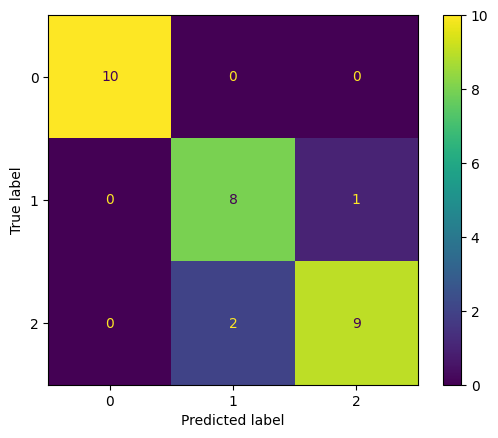

In [144]:
# 7. Report the confusion matrix.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

conf_mat = confusion_matrix(y_test, preds, labels=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])
cm_plt = ConfusionMatrixDisplay(conf_mat)
cm_plt.plot()
plt.show()